# Projeto de Ciência de Dados

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Agora que vimos os conceitos básicos de Ciência de Dados, estamos prontos para desenvolver um projeto completo. As fases envolvidas no processo podem ser resumidas nos seguintes passos:<br>
1 - Formulação do problema e preparo dos dados<br>
2 - Limpeza e engenharia de atributos<br>
3 - Codificação e normalização dos dados<br>
4 - Análise exploratória de dados<br>
5 - Adversarial Validation<br>
6 - Aprendizado supervisionado através da validação cruzada<br>
7 - Classificação com os melhores hiperparâmetros<br>
8 - Comparação com outros modelos<br>
9 - Classificação com múltiplos modelos e validação cruzada

Nessa aula, vamos considerar todos esses passos, de modo a construir um projeto de Ciência de Dados típico, incluindo uma etapa de engenharia de atributos, que costuma ser decisiva para melhorar o desempenho dos modelos.

Vamos considerar o problema de classificação dos passageiros do Titanic disponível no portal Kaggle: https://www.kaggle.com/c/titanic. Ou seja, objetivamos construir um projeto para classificar os dados e posterior submissão, de modo a verificar o quão preciso são nossos resultados comparados com soluções de outros usuários. Vamos mostrar todas as fases do projeto e os resultados, mas lembramos que essa é uma possível solução. Um cientista de dados deve aprender com os erros e sempre tentar melhorar um projeto, aprendendo em todas as fases de seu desenvolvimento.

## 1 - Formulação do problema e leitura dos dados

Vamos considerar a base de dados de passageiros que viajaram no Titanic.

Os atributos contidos nos dados:<br>
1. `PassengerId`: número de identificação do passageiro;<br>
2. `Survived`: indica se o passageiro sobreviveu ao desastre (0 = não sobreviveu, 1 = sobreviveu) — **variável-alvo**;<br>
3. `Pclass`: classe em que o passageiro viajou (1ª, 2ª ou 3ª classe);<br>
4. `Name`: nome do passageiro;<br>
5. `Sex`: sexo do passageiro;<br>
6. `Age`: idade do passageiro, em anos;<br>
7. `SibSp`: quantidade de irmãos e cônjuges a bordo;<br>
8. `Parch`: quantidade de pais e filhos a bordo;<br>
9. `Ticket`: número da passagem;<br>
10. `Fare`: preço da passagem;<br>
11. `Cabin`: número da cabine do passageiro;<br>
12. `Embarked`: porto no qual o passageiro embarcou (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).

**Nosso objetivo é classificar os passageiros como sobreviventes (ou não) de acordo com o conjunto de atributos.**

Fazendo a leitura dos dados:

In [79]:
import random
random.seed(42)  # define a semente (importante para reproduzir os resultados)
import numpy as np
np.random.seed(42)
import pandas as pd
import matplotlib.pyplot as plt

# Caminho local dos dados
# LOCAL_TRAIN_PATH = 'data/titanic/train.csv'
# LOCAL_TEST_PATH = 'data/titanic/test.csv'

# import os

# if os.path.exists(LOCAL_TRAIN_PATH) and os.path.exists(LOCAL_TEST_PATH):
#     # Lê do computador local (ou do ambiente onde o notebook está rodando)
#     train = pd.read_csv(LOCAL_TRAIN_PATH, header=0)
#     test = pd.read_csv(LOCAL_TEST_PATH, header=0)
# else:
#     # Se os arquivos não estiverem localmente, tenta montar o Google Drive (ambiente Colab)
#     from google.colab import drive
#     drive.mount('/content/drive/')
#     train = pd.read_csv('/content/drive/My Drive/data/titanic/train.csv', header=0)
#     test = pd.read_csv('/content/drive/My Drive/data/titanic/test.csv', header=0)

train = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\14-Projeto_titanic\data\train.csv', header=0)
test = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\14-Projeto_titanic\data\test.csv', header=0)

print("Número de linhas e colunas no conjunto de treinamento:", train.shape)
print("Número de linhas e colunas no conjunto de teste:", test.shape)

print('Conjunto de treinamento:')
train.head(10)

Número de linhas e colunas no conjunto de treinamento: (891, 12)
Número de linhas e colunas no conjunto de teste: (418, 11)
Conjunto de treinamento:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Notem que temos um conjunto de treinamento, que geralmente temos acesso em projetos de Ciência de Dados, e um conjunto de teste, que representa a aplicação de nosso modelo desenvolvido. É importante notar que, na prática, não vamos conhecer os resultados de problemas de classificação ou regressão, isto é, a saída $y$, no conjunto de teste. No entanto, em nosso exemplo vamos poder submeter as soluções (a classificação do conjunto de teste) e verificar o quão boa é a nossa metodologia, comparando ainda com outras soluções apresentadas no site Kaggle. Em casos reais, as predições também poderão ser comparadas com resultados de casos desconhecidos ou predições futuras, como no caso de diagnóstico de doenças ou predição de preços no mercado de ações, isto é, um médico pode confirmar um diagnóstico, bem como poderemos comparar a predição com o valor de uma ação no futuro.

Assim, os dados no conjunto de teste não contém as classes, que devemos inferir.

In [80]:
print('Conjunto de teste:')
test.head(10)

Conjunto de teste:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


Após a leitura dos dados e formulação dos problemas, podemos passar à fase de limpeza e engenharia de atributos.

## 2 - Limpeza e engenharia de atributos

Vemos que alguns atributos são irrelavantes, como `PassengerId`, `Name`, `Ticket` e `Cabin`. Vamos retirar esses atributos dos conjuntos de teste e treinamento. No entanto, usaremos o atributo `PassengerId` quando formos submeter nossa solução no Kaggle. 

No entanto, antes de descartar atributos como `Name`, `Ticket` e `Cabin`, vale a pena extrair deles informações úteis. Esse processo se chama **engenharia de atributos** (*feature engineering*) e costuma ter grande impacto no desempenho dos modelos,  muitas vezes maior do que a escolha do algoritmo de classificação.

Vamos guardar o `PassengerId` do conjunto de teste, pois ele será necessário na submissão ao Kaggle, e então construir os seguintes atributos novos:

- **Title**: título extraído do nome do passageiro (`Mr`, `Mrs`, `Miss`, `Master` etc.), que carrega informação sobre gênero, idade aproximada e status social;
- **FamilySize**: tamanho total da família a bordo (`SibSp` + `Parch` + 1);
- **IsAlone**: indica se o passageiro viajava sozinho;
- **TicketGroupSize**: número de passageiros que compartilham o mesmo bilhete (uma aproximação do tamanho do grupo de viagem, incluindo não-familiares);
- **FarePerPerson**: tarifa dividida pelo tamanho do grupo do bilhete, uma estimativa da tarifa individual;
- **Deck**: primeira letra da cabine, quando disponível, que indica a posição do passageiro no navio.

Depois de extrair essas informações, as colunas originais `PassengerId`, `Name`, `Ticket` e `Cabin` podem ser descartadas.

In [81]:
PassengerId_test = test['PassengerId']

def create_features(df):
    df = df.copy()

    # Título extraído do nome (texto entre a vírgula e o ponto)
    df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()

    # Agrupa títulos raros em uma única categoria
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
                   'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Tamanho da família a bordo
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # Indica se o passageiro viajava sozinho
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Número de passageiros associados ao mesmo bilhete
    ticket_counts = df['Ticket'].value_counts()
    df['TicketGroupSize'] = df['Ticket'].map(ticket_counts) 

    # Tarifa por pessoa (evita divisão por zero)
    df['FarePerPerson'] = df['Fare'] / df['TicketGroupSize'].replace(0, 1)

    # Primeira letra da cabine; 'Unknown' quando não informado
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('Unknown')

    return df


train = create_features(train)
test = create_features(test)

# Guardamos uma cópia com os atributos legíveis (antes do one-hot-encoding) para a análise exploratória
train_original = train.copy()

train[['Name', 'Title', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'FarePerPerson', 'Deck']].head(10)

,Name,Title,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Deck
0,"Braund, Mr. Owen Harris",Mr,2,0,1,7.25000,Unknown
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1,71.28330,C
2,"Heikkinen, Miss. Laina",Miss,1,1,1,7.92500,Unknown
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,2,26.55000,C
4,"Allen, Mr. William Henry",Mr,1,1,1,8.05000,Unknown
5,"Moran, Mr. James",Mr,1,1,1,8.45830,Unknown
6,"McCarthy, Mr. Timothy J",Mr,1,1,1,51.86250,E
7,"Palsson, Master. Gosta Leonard",Master,5,0,4,5.26875,Unknown
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,3,3.71110,Unknown
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,2,15.03540,Unknown


Agora podemos descartar os atributos que já foram resumidos pelos novos atributos, além do identificador `PassengerId`, que não carrega informação preditiva.

In [82]:
train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
train.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Deck
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,1,7.25000,Unknown
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1,71.28330,C
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,1,7.92500,Unknown
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,2,26.55000,C
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,1,8.05000,Unknown
5,0,3,male,NaN,0,0,8.4583,Q,Mr,1,1,1,8.45830,Unknown
6,0,1,male,54.0,0,0,51.8625,S,Mr,1,1,1,51.86250,E
7,0,3,male,2.0,3,1,21.0750,S,Master,5,0,4,5.26875,Unknown
8,1,3,female,27.0,0,2,11.1333,S,Mrs,3,0,3,3.71110,Unknown
9,1,2,female,14.0,1,0,30.0708,C,Mrs,2,0,2,15.03540,Unknown


O conjunto de dados pode apresentar valores nulos (*not a number: nan*). A sua identificação pode ser feita usando-se métodos da biblioteca Pandas.

Vamos verificar quantos valores nulos temos em nossos dados.

In [83]:
train.isnull().sum().sort_values(ascending=False).head(10)

Age           177
Embarked        2
Pclass          0
Sex             0
SibSp           0
Survived        0
Parch           0
Fare            0
Title           0
FamilySize      0
dtype: int64

In [84]:
test.isnull().sum().sort_values(ascending=False).head(10)

Age              86
FarePerPerson     1
Fare              1
Pclass            0
Sex               0
Parch             0
SibSp             0
Title             0
Embarked          0
FamilySize        0
dtype: int64

Se removermos as linhas com esses valores, vamos perder uma grande quantidade de dados. Para não descartarmos as observações que contêm `nan`, vamos atribuir valores médios às entradas nulas nos dados numéricos e a moda nos atributos nominais. Essa é a estratégia mais simples possível; outras mais sofisticadas, que consideram modelos de regressão para realizar a predição, também podem ser usadas.

**Importante:** as estatísticas (média e moda) devem ser calculadas **apenas com o conjunto de treinamento** e depois aplicadas também ao conjunto de teste. Calcular a média/moda separadamente em cada conjunto causaria vazamento de informação sobre a distribuição do conjunto de teste, além de tornar os dois conjuntos inconsistentes entre si.

In [85]:
# Estatísticas calculadas somente no conjunto de treinamento
age_mean = train['Age'].mean() 
fare_mean = train['Fare'].mean() 
embarked_mode = train['Embarked'].mode()[0] 

# Preenchimento do conjunto de treinamento
train['Age'] = train['Age'].fillna(age_mean)
train['Embarked'] = train['Embarked'].fillna(embarked_mode)
train['Fare'] = train['Fare'].fillna(fare_mean)

# Preenchimento do conjunto de teste usando as estatísticas do treinamento
test['Age'] = test['Age'].fillna(age_mean)
test['Embarked'] = test['Embarked'].fillna(embarked_mode)
test['Fare'] = test['Fare'].fillna(fare_mean)

# FarePerPerson pode ter ficado nulo se Fare estava ausente; recalculamos com a Fare já preenchida
train['FarePerPerson'] = train['Fare'] / train['TicketGroupSize'].replace(0, 1)
test['FarePerPerson'] = test['Fare'] / test['TicketGroupSize'].replace(0, 1)

# Atualiza também a cópia usada na análise exploratória
train_original['Age'] = train['Age']
train_original['Embarked'] = train['Embarked']
train_original['Fare'] = train['Fare']
train_original['FarePerPerson'] = train['FarePerPerson']

Vamos verificar novamente se os dados ainda contém valores nulos.

In [86]:
train.isnull().sum().sort_values(ascending=False).head(10)

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
dtype: int64

In [87]:
test.isnull().sum().sort_values(ascending=False).head(10)

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

Vejos que agora o conjunto de dados está completo.

## 3 - Codificação e normalização dos dados

Os atributos nominais podem ser transformados para numéricos usando **one-hot-encoding**. Um ponto de atenção aqui: se aplicarmos `pd.get_dummies` separadamente em `train` e `test`, as colunas geradas podem ficar diferentes entre os dois conjuntos (por exemplo, se uma categoria aparecer em um conjunto e não no outro). Para evitar esse problema, concatenamos temporariamente os dois conjuntos, aplicamos o one-hot-encoding uma única vez e depois separamos novamente.

In [88]:
# Guarda o número de linhas do conjunto de treinamento.
# Essa informação será usada depois para separar novamente os conjuntos de treinamento e teste.
train_rows = len(train)

# A variável-alvo "Survived" existe apenas no conjunto de treinamento.
# Por isso, ela deve ser retirada antes de juntar treino e teste.
y_full = train["Survived"].copy()

# Cria uma nova tabela contendo apenas os atributos do treinamento, sem a variável que queremos prever.
train_features = train.drop(columns=["Survived"])

# Junta os atributos do treinamento e do teste em uma única tabela.
# Isso garante que a criação das variáveis dummy considere todas as categorias existentes nos dois conjuntos.
# axis=0 indica que as tabelas serão empilhadas por linhas.
# ignore_index=True cria um novo índice sequencial. Não altera os dados das colunas; ele apenas reorganiza o índice das linhas, começando por zero.
combined = pd.concat(
    [train_features, test],
    axis=0,
    ignore_index=True
)

# Converte as variáveis categóricas em variáveis numéricas dummy.
# Por exemplo, uma coluna "Sex" com as categorias: "female" e "male"
# pode ser transformada em uma coluna: "Sex_male"
# Com drop_first=True, a primeira categoria de cada variável é removida para evitar redundância entre as colunas criadas.
combined = pd.get_dummies(combined,drop_first=True)

# Recupera as primeiras linhas da tabela combinada.
# Como o treinamento foi colocado antes do teste, as primeiras train_rows linhas correspondem ao treinamento.
train = combined.iloc[:train_rows,:].copy()

# Recoloca a variável-alvo no conjunto de treinamento.
# O uso de .values evita que o pandas tente alinhar os dados pelo índice original.
train["Survived"] = y_full.values

# Recupera as linhas restantes da tabela combinada. Essas linhas correspondem ao conjunto de teste.
test = combined.iloc[train_rows:,:].copy()

# Verifica se treino e teste possuem os mesmos atributos.
# A única diferença esperada é que o conjunto de treinamento possui a coluna "Survived", enquanto o conjunto de teste não possui.
same_columns = (set(test.columns)== set(train.columns) - {"Survived"})

print("Colunas de treino e teste são idênticas (exceto Survived):",
      set(test.columns) == set(train.columns) - {'Survived'})
train.head(10)

# Exibe as dez primeiras linhas do conjunto de treinamento após a transformação das variáveis categóricas.
train.head(10)

Colunas de treino e teste são idênticas (exceto Survived): True


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Sex_male,...,Title_the Countess,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Survived
0,3,22.000000,1,0,7.2500,2,0,1,7.25000,True,...,False,False,False,False,False,False,False,False,True,0
1,1,38.000000,1,0,71.2833,2,0,1,71.28330,False,...,False,False,True,False,False,False,False,False,False,1
2,3,26.000000,0,0,7.9250,1,1,1,7.92500,False,...,False,False,False,False,False,False,False,False,True,1
3,1,35.000000,1,0,53.1000,2,0,2,26.55000,False,...,False,False,True,False,False,False,False,False,False,1
4,3,35.000000,0,0,8.0500,1,1,1,8.05000,True,...,False,False,False,False,False,False,False,False,True,0
5,3,29.699118,0,0,8.4583,1,1,1,8.45830,True,...,False,False,False,False,False,False,False,False,True,0
6,1,54.000000,0,0,51.8625,1,1,1,51.86250,True,...,False,False,False,False,True,False,False,False,False,0
7,3,2.000000,3,1,21.0750,5,0,4,5.26875,True,...,False,False,False,False,False,False,False,False,True,0
8,3,27.000000,0,2,11.1333,3,0,3,3.71110,False,...,False,False,False,False,False,False,False,False,True,1
9,2,14.000000,1,0,30.0708,2,0,2,15.03540,False,...,False,False,False,False,False,False,False,False,True,1


Para facilitar o processamento, vamos converter os dados para o formato numpy para podemos realizar a classificação.

In [89]:
data_train = train.to_numpy()
nrow, ncol = data_train.shape

target_idx = train.columns.get_loc('Survived')
y_train = data_train[:, target_idx].astype(int)

X_train = np.delete(data_train, target_idx, axis=1)
feature_names = train.columns.drop('Survived')

Para o conjunto de teste:

In [90]:
X_test = test.to_numpy()

Vamos verificar se as classes estão balanceadas.

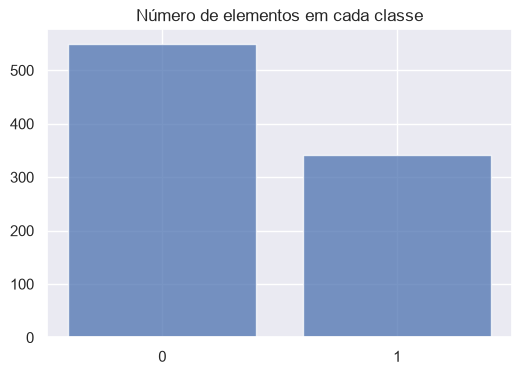

In [91]:
classes = y_train
cl = np.unique(classes)
ncl = np.zeros(len(cl))
for i in np.arange(0, len(cl)):
    a = classes == cl[i]
    ncl[i] = len(classes[a])

numbers = np.arange(0, len(cl))
plt.figure(figsize=(6, 4))
plt.bar(numbers, ncl, alpha=.75)
plt.xticks(numbers, cl)
plt.title('Número de elementos em cada classe')
plt.show()

Ou seja, há mais não-sobreviventes do que sobreviventes. Essa informação será importante na validação cruzada.

Vamos normalizar os dados. A padronização (média zero e desvio padrão um) é ajustada **apenas com os dados de treinamento** e depois aplicada ao teste, para evitar vazamento de informação.

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print('Dados de treinamento transformados:')
print('Média: ', np.round(np.mean(X_train, axis=0), 2))
print('Desvio padrão:', np.round(np.std(X_train, axis=0), 2))

print('\nDados de teste transformados:')
print('Média: ', np.round(np.mean(X_test, axis=0), 2))
print('Desvio padrão:', np.round(np.std(X_test, axis=0), 2))

Dados de treinamento transformados:
Média:  [-0.  0.  0.  0.  0. -0. -0.  0.  0. -0.  0. -0.  0. -0.  0.  0.  0.  0.
 -0. -0. -0. -0.  0.  0. -0.]
Desvio padrão: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]

Dados de teste transformados:
Média:  [-0.05  0.04 -0.07  0.01  0.07 -0.04  0.01 -0.32  0.3  -0.02  0.08 -0.18
 -0.05 -0.01  0.09 -0.07 -0.03 -0.04  0.07 -0.03 -0.08  0.04 -0.03 -0.03
  0.03]
Desvio padrão: [1.01 0.97 0.81 1.22 1.12 0.94 1.   0.56 1.74 1.01 1.11 1.07 0.97 1.
 1.08 0.77 0.   0.91 1.11 0.92 0.78 1.14 0.73 0.   0.98]


## 4 - Análise exploratória de dados

Podemos analisar as variáveis individualmente ou sua relação, de modo a entender melhor os dados. Usamos aqui `train_original`, que mantém os atributos em formato legível (antes do one-hot-encoding).

Inicialmente, vamos analisar a correlação entre os atributos numéricos.

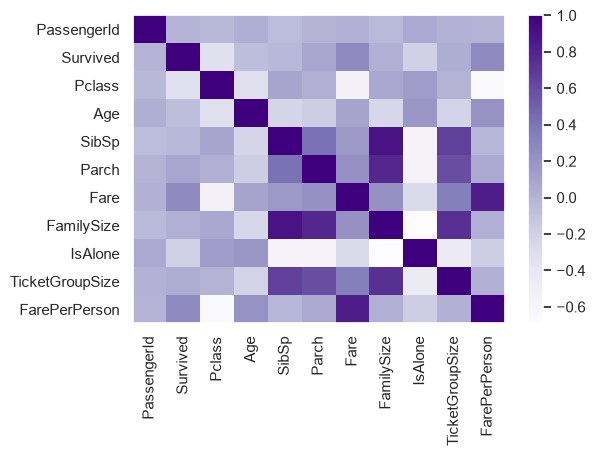

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson
PassengerId,1.00,-0.01,-0.04,0.03,-0.06,-0.00,0.01,-0.04,0.06,0.00,-0.00
Survived,-0.01,1.00,-0.34,-0.07,-0.04,0.08,0.26,0.02,-0.20,0.04,0.25
Pclass,-0.04,-0.34,1.00,-0.33,0.08,0.02,-0.55,0.07,0.14,-0.00,-0.66
Age,0.03,-0.07,-0.33,1.00,-0.23,-0.18,0.09,-0.25,0.18,-0.22,0.21
SibSp,-0.06,-0.04,0.08,-0.23,1.00,0.41,0.16,0.89,-0.58,0.66,-0.01
Parch,-0.00,0.08,0.02,-0.18,0.41,1.00,0.22,0.78,-0.58,0.59,0.06
Fare,0.01,0.26,-0.55,0.09,0.16,0.22,1.00,0.22,-0.27,0.35,0.84
FamilySize,-0.04,0.02,0.07,-0.25,0.89,0.78,0.22,1.00,-0.69,0.75,0.02
IsAlone,0.06,-0.20,0.14,0.18,-0.58,-0.58,-0.27,-0.69,1.00,-0.46,-0.18
TicketGroupSize,0.00,0.04,-0.00,-0.22,0.66,0.59,0.35,0.75,-0.46,1.00,0.01


In [93]:
corr = train_original.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap='Purples', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns)
plt.grid(False)
plt.show()

# Exibe a matriz de correlação em formato de tabela
# round(2) arredonda os valores para duas casas decimais
display(corr.round(2))

A variável mais associada à sobrevivência é `Pclass`, com correlação negativa. Isso indica que, à medida que o número da classe aumenta, a sobrevivência tende a diminuir. Como a primeira classe é codificada por 1 e a terceira por 3, passageiros das classes mais altas economicamente tiveram maior probabilidade de sobreviver.

`Fare` e `FarePerPerson` apresentam correlação positiva com `Survived`. Isso sugere que passageiros que pagaram tarifas maiores, ou maiores tarifas por pessoa, tiveram maior chance de sobrevivência. Essa relação também está ligada à classe do passageiro, pois `Pclass` possui forte correlação negativa com `FarePerPerson`.

`IsAlone` apresenta correlação negativa com `Survived`, indicando que passageiros que viajavam sozinhos tenderam a sobreviver menos. Já `FamilySize`, `SibSp`, `Parch` e `TicketGroupSize` mostram associações fracas com a sobrevivência, pelo menos do ponto de vista linear.

A idade apresenta correlação pequena e negativa com `Survived`. Isso não significa que a idade seja irrelevante. É possível que a relação seja não linear, por exemplo, crianças apresentando maior sobrevivência do que adultos, sem que isso produza uma correlação linear forte.

Também aparecem correlações elevadas entre variáveis explicativas:

* `FamilySize` é fortemente correlacionada com `SibSp` e `Parch`, o que é esperado, pois foi construída a partir dessas variáveis;
* `FamilySize` e `TicketGroupSize` também apresentam correlação positiva;
* `IsAlone` possui forte correlação negativa com `FamilySize`, `SibSp`, `Parch` e `TicketGroupSize`;
* `Fare` e `FarePerPerson` são fortemente correlacionadas;
* `Pclass` possui forte correlação negativa com `FarePerPerson`.

Para confirmar esse resultado, vamos analisar os dados de arcordo com o gênero. Observamos que a taxa de sobrevivência dos homens foi em torno de 25%, enquanto que a das mulheres, de 75%. Portanto, saber se o passageiro era homem ou mulher é uma informaçãom importante a ser levada em conta na classificação.

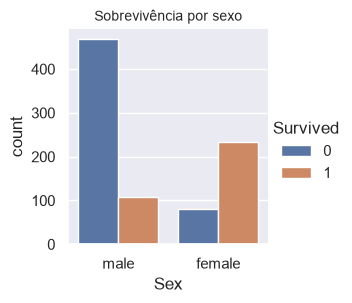

In [94]:
import seaborn as sns

sns.catplot(x="Sex", hue="Survived", kind="count", data=train_original, height=3, aspect=1)
plt.title("Sobrevivência por sexo", fontsize = 10)
plt.show()

Vamos analisar a relação entre a classe do passageiro e se o passageiro sobreviveu. Conforme observamos a seguir, grande parte das mortes ocorreram entre os passageiros da terceira classe. Portanto, essa informação também é importante para classificarmos os passageiros em sobreviventes.

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


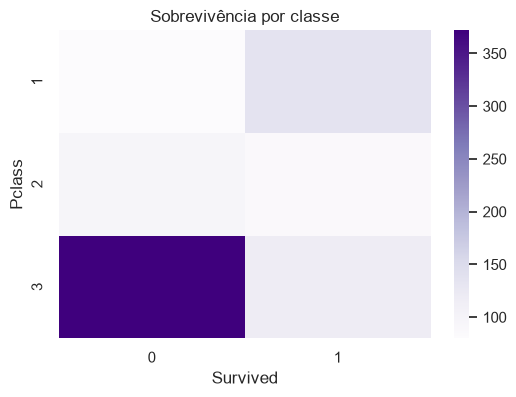

In [95]:
import seaborn as sns
# define os tamanhos dos plots usando o sns
sns.set_theme(rc={'figure.figsize':(6, 4)})

group = train_original.groupby(['Pclass', 'Survived'])
pclass_survived = group.size().unstack()
sns.heatmap(pclass_survived, annot=False, fmt="d", cmap='Purples')
plt.title("Sobrevivência por classe")
print(pclass_survived)
plt.show()

De acordo com a idade, vemos que boa parte das crianças sobreviveram. Além disso, as mulheres com mais idade e os homens mais jovens apresentaram uma chance maior de sobrevier.

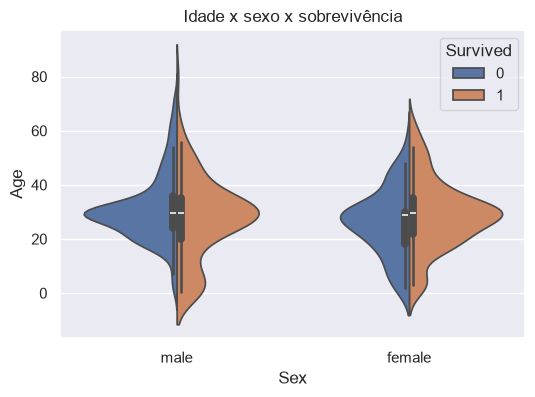

In [96]:
sns.violinplot(x="Sex", y="Age", hue="Survived", data=train_original, split=True)
plt.title("Idade x sexo x sobrevivência")
plt.show()

De acordo com o preço do bilhete, vemos que quanto mais caro, maior tende a ser a chance de sobrevivência, o que reforça que a classe de embarque é uma variável importante.

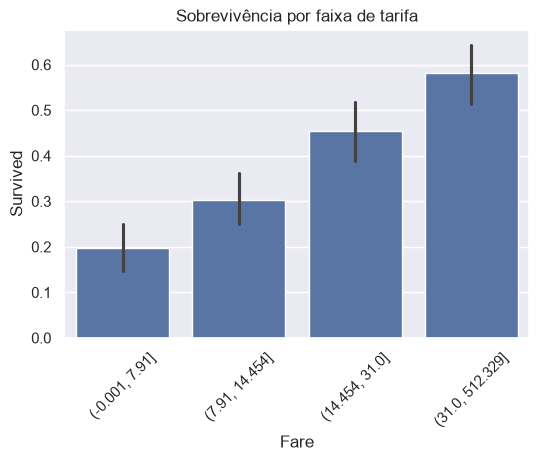

In [97]:
fare_range = pd.qcut(train_original['Fare'], 4, duplicates='drop')
sns.barplot(x=fare_range, y='Survived', data=train_original)
plt.title("Sobrevivência por faixa de tarifa")
plt.xticks(rotation=45)
plt.show()

De acordo com o porto de embarque, notamos que a maioria dos sobreviventes são do porto de Southampton (S). Além disso, em Queenstown (Q) embaracaram a maioria dos passageiros da terceira classe.

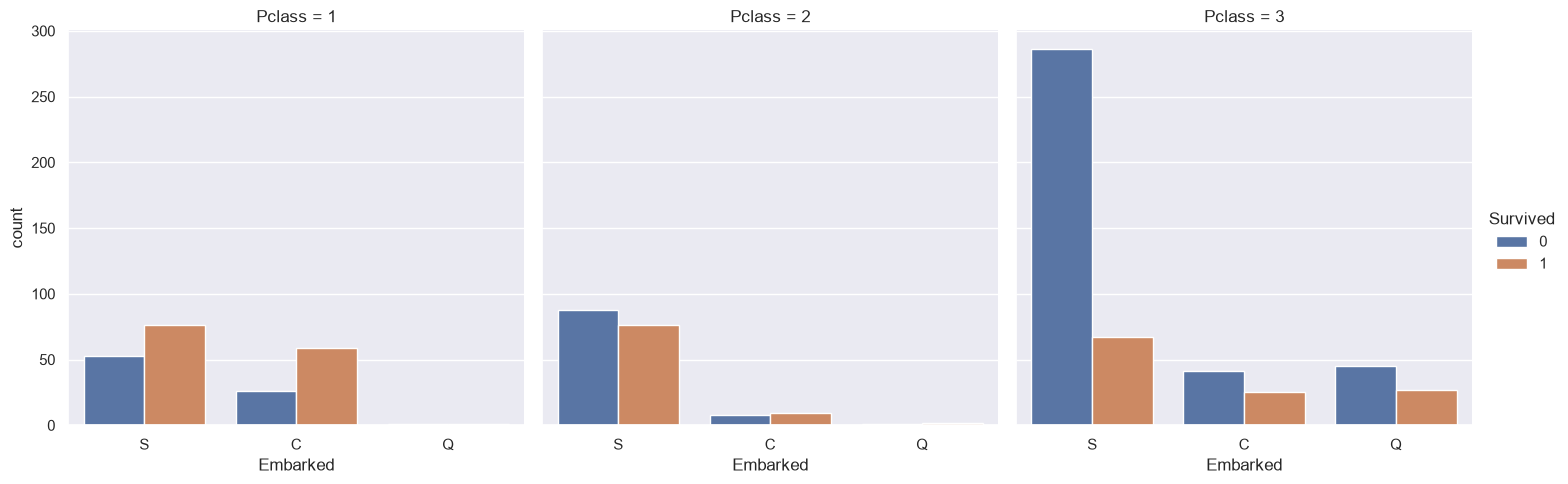

In [98]:
sns.catplot(x='Embarked', hue='Survived', kind='count', col='Pclass', data=train_original)
plt.show()

Vamos agora analisar os **novos atributos** criados na engenharia de atributos: `Title`, `FamilySize`, `IsAlone` e `Deck`.

No gráfico a seguir, confirmamos que as mulheres tiveram uma chance maior de sobreviver.

,Taxa de sobrevivência,Quantidade
Title,,
the Countess,1.000000,1
Mrs,0.793651,126
Miss,0.702703,185
Master,0.575000,40
Rare,0.318182,22
Mr,0.156673,517


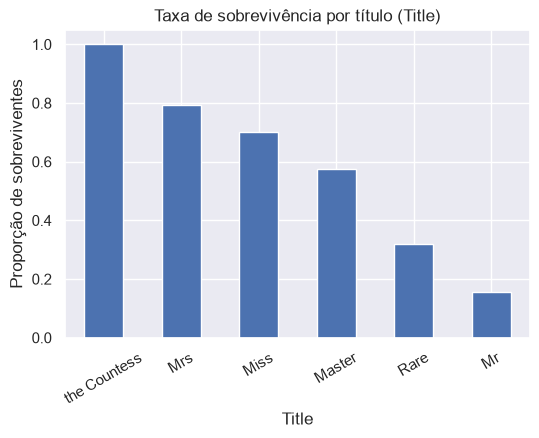

In [99]:
title_survival = (
    train_original.groupby('Title')['Survived']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Taxa de sobrevivência', 'count': 'Quantidade'})
    .sort_values('Taxa de sobrevivência', ascending=False)
)
display(title_survival)

title_survival['Taxa de sobrevivência'].plot(kind='bar')
plt.ylabel('Proporção de sobreviventes')
plt.title('Taxa de sobrevivência por título (Title)')
plt.xticks(rotation=30)
plt.show()

,Taxa de sobrevivência,Quantidade
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


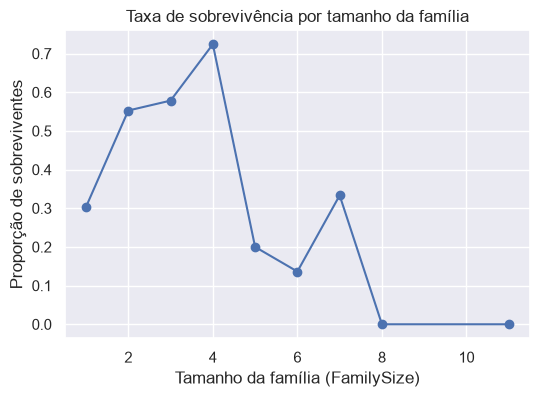

In [100]:
family_survival = (
    train_original.groupby('FamilySize')['Survived']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Taxa de sobrevivência', 'count': 'Quantidade'})
)
display(family_survival)

family_survival['Taxa de sobrevivência'].plot(marker='o')
plt.xlabel('Tamanho da família (FamilySize)')
plt.ylabel('Proporção de sobreviventes')
plt.title('Taxa de sobrevivência por tamanho da família')
plt.show()

Vemos que passageiros que viajavam completamente sozinhos (`FamilySize = 1`) tendem a ter menor taxa de sobrevivência do que aqueles com uma família pequena, mas famílias muito grandes também sofrem, possivelmente por dificuldade de se manterem juntas durante a evacuação.

Portanto, vemos que vários atributos, tanto os originais quanto os construídos na engenharia de atributos, são importantes para separar as classes.

## 5 - Adversarial Validation

A validação adversarial é uma técnica para medir a semelhança entre conjuntos de dados de treino e teste. A ideia é treinar um classificador binário para prever se uma amostra vem do conjunto de treino ou de teste. Se o modelo conseguir distinguir facilmente entre os dois conjuntos, é porque há diferenças significativas entre eles, o que pode prejudicar a generalização do modelo e indicar que o mesmo pode não ter um bom desempenho em dados novos.

A ideia é transformar o problema em uma nova tarefa de classificação:
- observações do conjunto de treinamento recebem o rótulo 0;
- observações do conjunto de teste recebem o rótulo 1.

Em seguida, treinamos um classificador para distinguir de qual conjunto cada observação veio.

Se a AUC é próxima de 0,5, então o classificador não consegue distinguir treinamento de teste.

Isso sugere que os dois conjuntos possuem distribuições semelhantes.

Vamos considerar o algoritmo Naive Bayes.

AUC da validação adversarial (Naive Bayes): 0.5964925373134329


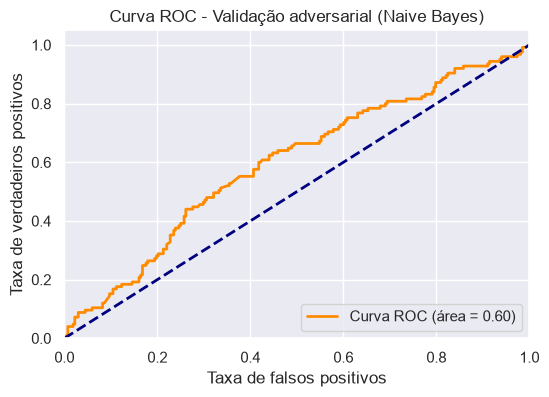

In [101]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split

# Concatena os dados de treino e teste
X_combined = np.concatenate((X_train, X_test), axis=0)

# Cria os rótulos (0 para treino, 1 para teste)
y_combined = np.array([0] * len(X_train) + [1] * len(X_test)) 

# Divide os dados combinados para a validação adversarial
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

nb_adv = GaussianNB()
nb_adv.fit(X_train_adv, y_train_adv)

y_pred_proba_adv_nb = nb_adv.predict_proba(X_test_adv)[:, 1]

fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test_adv, y_pred_proba_adv_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

print("AUC da validação adversarial (Naive Bayes):", roc_auc_nb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc_nb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC - Validação adversarial (Naive Bayes)')
plt.legend(loc='lower right')
plt.show()

Um valor de AUC próximo de 0.5 indica que o classificador não consegue distinguir treino de teste, ou seja, os dois conjuntos têm distribuições semelhantes — o que é uma boa notícia para a generalização do nosso modelo. Vamos repetir a análise usando um Random Forest, que pode capturar relações não lineares mais complexas entre os atributos.

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_adv = {
    'n_estimators': [10, 50],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_adv = RandomForestClassifier(random_state=42)
grid_search_adv = GridSearchCV(
    estimator=rf_adv, param_grid=param_grid_adv, cv=5, scoring='roc_auc', verbose=0, n_jobs=-1
)
grid_search_adv.fit(X_train_adv, y_train_adv)

print("Melhores hiperparâmetros:", grid_search_adv.best_params_)
print("Melhor AUC na validação cruzada:", grid_search_adv.best_score_)

y_pred_adv = grid_search_adv.predict_proba(X_test_adv)[:, 1]
auc_adv = roc_auc_score(y_test_adv, y_pred_adv)
print("AUC no conjunto de teste (validação adversarial):", auc_adv)

Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Melhor AUC na validação cruzada: 0.6585040025640542
AUC no conjunto de teste (validação adversarial): 0.6336567164179103


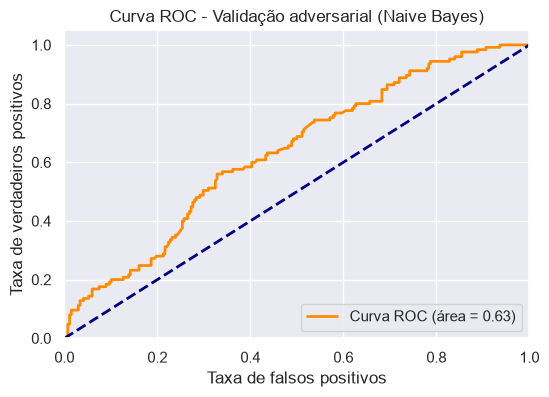

In [105]:
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test_adv, y_pred_adv)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc_nb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC - Validação adversarial (Naive Bayes)')
plt.legend(loc='lower right')
plt.show()

Os resultados são similares ao do Naive Bayes, ou seja, dois conjuntos têm distribuições semelhantes.

## 6 - Seleção e ajuste do modelo

Vamos comparar diversos métodos de classificação, usando validação cruzada. Como os dados podem ser desbalanceados, precisamos levar essa informação em conta na validação. Para medir a qualidade da classificação, vamos usar a área sob a curva ROC (AUC), pois temos apenas duas classes, e vamos manter essa métrica consistente em todos os classificadores comparados.

Vamos utilizar validação cruzada com o classificador KNN (k-vizinhos mais próximos).

In [106]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
k_range = list(range(1, 51))
param_grid = [{'n_neighbors': k_range, 'metric': ['euclidean', 'minkowski', 'chebyshev']}]

# Usamos AUC como métrica de seleção, para manter consistência com os demais modelos
model = GridSearchCV(estimator=knn, param_grid=param_grid, cv=10, scoring='roc_auc',
                      return_train_score=False, verbose=0, n_jobs=-1)

model.fit(X_train, y_train)
print("Melhores hiperparâmetros (KNN):", model.best_params_)
print("Melhor AUC média na validação cruzada (KNN):", model.best_score_)
model.score(X_train, y_train)

Melhores hiperparâmetros (KNN): {'metric': 'euclidean', 'n_neighbors': 7}
Melhor AUC média na validação cruzada (KNN): 0.8642883173471407


0.9273399801872623

## 7 - Classificação

Após encontrar os melhores hiperparâmetros, podemos fazer a classificação usando o método dos k-vizinhos nos dados desconhecidos. Os resultados serão gravados em um arquivo para submetermos ao Kaggle.

In [108]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
y_pred = np.array(y_pred, dtype=int)

prediction = pd.DataFrame()
prediction['PassengerId'] = PassengerId_test
prediction['Survived'] = y_pred

print("Acurácia no treinamento:", model.score(X_train, y_train))
prediction.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-knn.csv', index=False)
prediction.head()

Acurácia no treinamento: 0.9273399801872623


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


Enviando essa solução para o Kaggle, é possível comparar o resultado com outros participantes da competição.

## 8 - Comparação com outros modelos

Vamos considerar outros modelos para tentar melhorar o resultado da classificação.

### 8.1 - Random forest

In [109]:
param_grid_rf = {
    'n_estimators': [10, 50],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=5,
                               scoring='roc_auc', verbose=0, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("Melhores hiperparâmetros (Random Forest):", grid_search_rf.best_params_)
print("Melhor AUC na validação cruzada (Random Forest):", grid_search_rf.best_score_)

y_train_pred_proba = grid_search_rf.predict_proba(X_train)[:, 1]
train_auc_rf = roc_auc_score(y_train, y_train_pred_proba)
print("AUC no conjunto de treinamento (Random Forest):", train_auc_rf)

# Previsão no conjunto de teste e geração do arquivo de submissão
y_pred_rf = grid_search_rf.predict(X_test)
y_pred_rf = np.array(y_pred_rf, dtype=int)

prediction_rf = pd.DataFrame()
prediction_rf['PassengerId'] = PassengerId_test
prediction_rf['Survived'] = y_pred_rf
prediction_rf.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-random-forest.csv', index=False)

prediction_rf.head()

Melhores hiperparâmetros (Random Forest): {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Melhor AUC na validação cruzada (Random Forest): 0.8775248999770341
AUC no conjunto de treinamento (Random Forest): 0.9630108970057201


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


No caso do classificador Random Forest, podemos ordenar os atributos de acordo com a sua importância — inclusive os que criamos na engenharia de atributos.

Importância dos atributos (Random Forest):
Deck_T: 0.0000
Title_the Countess: 0.0000
Deck_G: 0.0006
Deck_F: 0.0009
Deck_C: 0.0036
Deck_B: 0.0041
Embarked_Q: 0.0055
IsAlone: 0.0070
Deck_E: 0.0078
Deck_D: 0.0083
Parch: 0.0101
Title_Rare: 0.0118
Embarked_S: 0.0127
SibSp: 0.0179
Title_Mrs: 0.0287
Deck_Unknown: 0.0300
FamilySize: 0.0365
Pclass: 0.0445
TicketGroupSize: 0.0487
Title_Miss: 0.0597
Age: 0.1017
Fare: 0.1022
FarePerPerson: 0.1110
Sex_male: 0.1639
Title_Mr: 0.1828


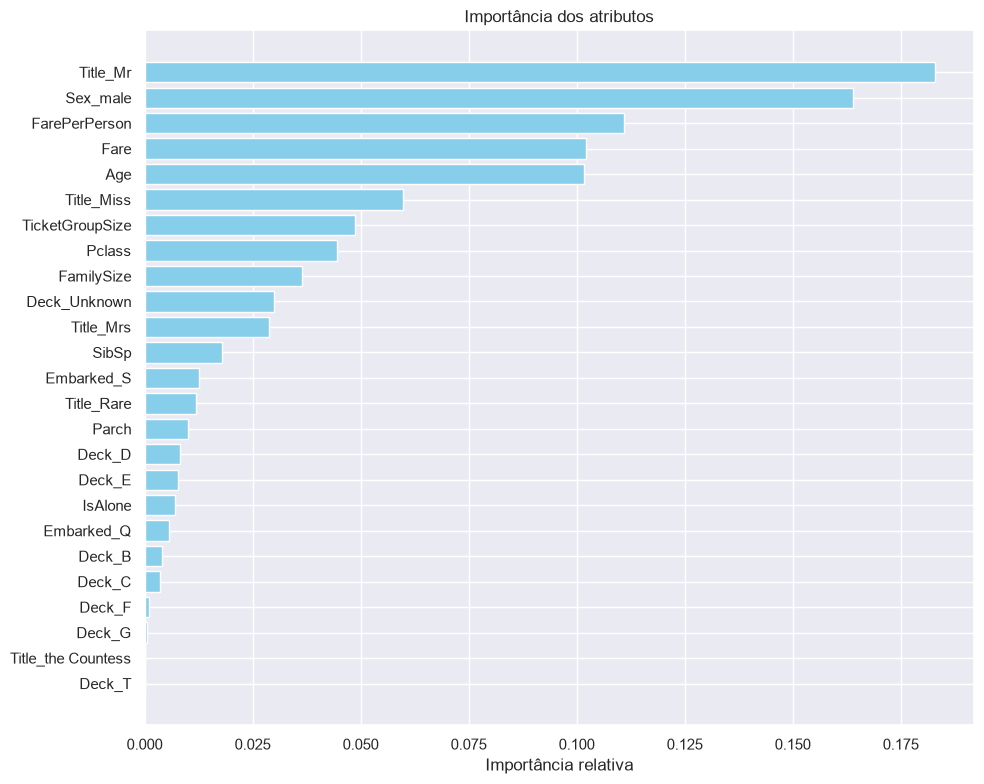

In [110]:
importances = grid_search_rf.best_estimator_.feature_importances_
indices = np.argsort(importances)
attributes_rank = [feature_names[i] for i in indices]

print("Importância dos atributos (Random Forest):")
for f in range(X_train.shape[1]):
    print(f"{attributes_rank[f]}: {importances[indices[f]]:.4f}")

plt.figure(figsize=(10, 8))
plt.title("Importância dos atributos")
plt.barh(range(X_train.shape[1]), importances[indices], color="skyblue", align="center")
plt.yticks(range(X_train.shape[1]), attributes_rank)
plt.xlabel("Importância relativa")
plt.tight_layout()
plt.show()

A importância dos atributos mostra que o gênero e o título do passageiro foram os fatores mais relevantes para a classificação entre sobreviventes e não sobreviventes. Variáveis relacionadas à condição socioeconômica, como tarifa e classe da passagem, também tiveram forte influência. A idade, o tamanho da família e o tamanho do grupo associado ao bilhete contribuíram de forma adicional. Esses resultados são coerentes com a política de resgate adotada no Titanic, na qual mulheres, crianças e passageiros das classes superiores apresentaram maior probabilidade de sobrevivência.

Para tentarmos melhorar a classificação, podemos considerar um número menor de atributos, escolhidos de acordo com a importância obtida no Random Forest.

In [111]:
ns = 8  # número de atributos selecionados

selected_attributes = list(attributes_rank[::-1][:ns])
print('Atributos selecionados:', selected_attributes)

train_selected_df = pd.DataFrame(X_train, columns=feature_names)[selected_attributes]
test_selected_df = pd.DataFrame(X_test, columns=feature_names)[selected_attributes]

X_train_selected = train_selected_df.to_numpy()
X_test_selected = test_selected_df.to_numpy()

param_grid_rf_selected = {
    'n_estimators': [10, 50],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_classifier_selected = RandomForestClassifier(random_state=42)
grid_search_rf_selected = GridSearchCV(estimator=rf_classifier_selected,
                                        param_grid=param_grid_rf_selected, cv=5,
                                        scoring='roc_auc', verbose=0, n_jobs=-1)
grid_search_rf_selected.fit(X_train_selected, y_train)

print("Melhores hiperparâmetros (RF com atributos selecionados):", grid_search_rf_selected.best_params_)
print("Melhor AUC na validação cruzada (RF com atributos selecionados):", grid_search_rf_selected.best_score_)

y_train_pred_proba_sel = grid_search_rf_selected.predict_proba(X_train_selected)[:, 1]
train_auc_rf_sel = roc_auc_score(y_train, y_train_pred_proba_sel)
print("AUC no conjunto de treinamento (RF com atributos selecionados):", train_auc_rf_sel)

Atributos selecionados: ['Title_Mr', 'Sex_male', 'FarePerPerson', 'Fare', 'Age', 'Title_Miss', 'TicketGroupSize', 'Pclass']
Melhores hiperparâmetros (RF com atributos selecionados): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Melhor AUC na validação cruzada (RF com atributos selecionados): 0.873835079957936
AUC no conjunto de treinamento (RF com atributos selecionados): 0.9638204497278411


Vemos que o uso desses atributos não piorou os resultados, mas simplificou o modelo, o que ajuda na interpretação e no tempo de processamento.

### 8.2 Naive Bayes

In [112]:
from sklearn.metrics import accuracy_score

nb_classifier_full = GaussianNB()
nb_classifier_full.fit(X_train, y_train)

y_train_pred_proba_nb_full = nb_classifier_full.predict_proba(X_train)[:, 1]
train_auc_nb_full = roc_auc_score(y_train, y_train_pred_proba_nb_full)
print("AUC no conjunto de treinamento (Naive Bayes):", train_auc_nb_full)

y_train_pred_nb_full = nb_classifier_full.predict(X_train)
train_accuracy_nb_full = accuracy_score(y_train, y_train_pred_nb_full)
print("Acurácia no conjunto de treinamento (Naive Bayes):", train_accuracy_nb_full)

# Previsão no conjunto de teste e geração do arquivo de submissão
y_pred_test_nb_full = nb_classifier_full.predict(X_test)
y_pred_test_nb_full = np.array(y_pred_test_nb_full, dtype=int)

prediction_nb = pd.DataFrame()
prediction_nb['PassengerId'] = PassengerId_test
prediction_nb['Survived'] = y_pred_test_nb_full
prediction_nb.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-naive-bayes.csv', index=False)
prediction_nb.head()

AUC no conjunto de treinamento (Naive Bayes): 0.8276291822452305
Acurácia no conjunto de treinamento (Naive Bayes): 0.7912457912457912


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Comparando os três modelos

Por fim, reunimos a AUC de validação cruzada dos três modelos considerados, para facilitar a comparação.

In [113]:
comparison = pd.DataFrame({
    'Modelo': ['KNN', 'Random Forest', 'Random Forest (atributos selecionados)', 'Naive Bayes'],
    'AUC (validação cruzada ou treino)': [
        model.best_score_,
        grid_search_rf.best_score_,
        grid_search_rf_selected.best_score_,
        train_auc_nb_full
    ]
}).sort_values('AUC (validação cruzada ou treino)', ascending=False)

display(comparison)

,Modelo,AUC (validação cruzada ou treino)
1,Random Forest,0.877525
2,Random Forest (atributos selecionados),0.873835
0,KNN,0.864288
3,Naive Bayes,0.827629


## 9 - Classificação com múltiplos modelos e validação cruzada

Nas seções anteriores, já experimentamos KNN, Random Forest e Naive Bayes de forma um pouco independente. Nesta seção final, vamos organizar tudo de um jeito mais sistemático e completo, comparando **quatro classificadores** lado a lado:

1. **KNN (k-vizinhos mais próximos)**;
2. **Árvore de decisão**;
3. **Regressão logística**;
4. **Floresta aleatória (Random Forest)**.

Para cada um deles, vamos:

- escolher os melhores hiperparâmetros por **validação cruzada**, usando a AUC como métrica (a mesma métrica usada nas seções anteriores, adequada para classes desbalanceadas como as do Titanic);
- avaliar o modelo escolhido em um conjunto de **validação** separado, calculando a **matriz de confusão** e as métricas de **acurácia, precisão (precision), recall, F1 e AUC**;
- no caso da árvore de decisão, veremos **duas formas diferentes de medir a importância dos atributos**;
- por fim, vamos reajustar todos os quatro modelos com **todos** os dados de treinamento disponíveis e gerar um arquivo de submissão para o Kaggle **para cada um deles**.

### 9.1 - Por que separar um conjunto de validação?

O arquivo `test.csv` do Kaggle não contém a coluna `Survived` — por isso, não conseguimos calcular matriz de confusão, precisão, recall ou F1 diretamente nele (essas métricas exigem saber o valor verdadeiro para comparar com a previsão). A solução é separar uma parte do **próprio conjunto de treinamento**, que já tem os rótulos verdadeiros, para servir como um "teste particular" nosso. Chamamos essa parte de **conjunto de validação**.

Importante: essa separação é feita **apenas para esta seção de avaliação** (matriz de confusão e métricas). Na etapa final de geração das submissões (Seção 9.7), voltamos a usar **todos** os dados de treinamento disponíveis para aproveitar o máximo de informação possível antes de prever o conjunto de teste real do Kaggle.

In [40]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
print("Tamanho do subconjunto de treinamento:", X_tr.shape)
print("Tamanho do conjunto de validação:     ", X_val.shape)

Tamanho do subconjunto de treinamento: (712, 25)
Tamanho do conjunto de validação:      (179, 25)


### 9.2 - Definindo os quatro modelos e seus hiperparâmetros

Cada classificador tem hiperparâmetros próprios, que controlam sua complexidade e forma de decisão. Vamos definir, para cada um, uma **grade de hiperparâmetros** a ser testada por validação cruzada:

- **KNN**: número de vizinhos (`n_neighbors`) e forma de pesar os vizinhos (`weights`);
- **Árvore de decisão**: profundidade máxima (`max_depth`), número mínimo de amostras para dividir um nó (`min_samples_split`) e para ser uma folha (`min_samples_leaf`), e o critério de divisão (`criterion`);
- **Regressão logística**: força da regularização (`C`) e se as classes devem ser ponderadas pelo desbalanceamento (`class_weight`);
- **Floresta aleatória**: número de árvores (`n_estimators`), profundidade máxima e os mesmos parâmetros de folha/divisão da árvore de decisão.

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_base = {
    "KNN": KNeighborsClassifier(),
    "Árvore de decisão": DecisionTreeClassifier(random_state=42),
    "Regressão logística": LogisticRegression(max_iter=5000, random_state=42),
    "Floresta aleatória": RandomForestClassifier(random_state=42, n_jobs=-1)
}

grades_hiperparametros = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
        "weights": ["uniform", "distance"]
    },
    "Árvore de decisão": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    },
    "Regressão logística": {
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    "Floresta aleatória": {
        "n_estimators": [50, 100],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }
}

### 9.3 - Ajuste dos hiperparâmetros por validação cruzada

Para cada modelo, usamos `GridSearchCV` com **validação cruzada estratificada em 5 partições** (a estratificação garante que a proporção de sobreviventes/não sobreviventes seja parecida em cada partição, importante já que as classes são desbalanceadas). A métrica de escolha é a **AUC média** entre as partições — é essa métrica que usamos tanto para escolher os hiperparâmetros de cada modelo quanto para comparar os quatro modelos entre si.

In [42]:
melhores_modelos_cv = {}
resumo_cv = []

for nome_modelo, estimador in modelos_base.items():
    print("=" * 70)
    print(f"Ajustando hiperparâmetros: {nome_modelo}")

    busca = GridSearchCV(
        estimator=estimador,
        param_grid=grades_hiperparametros[nome_modelo],
        cv=cv_split,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )
    busca.fit(X_tr, y_tr)

    melhores_modelos_cv[nome_modelo] = busca.best_estimator_
    resumo_cv.append({
        "Modelo": nome_modelo,
        "Melhor AUC média (validação cruzada)": busca.best_score_,
        "Melhores hiperparâmetros": busca.best_params_
    })

    print(f"Melhor AUC média: {busca.best_score_:.4f}")
    print(f"Melhores hiperparâmetros: {busca.best_params_}")

resumo_cv_df = pd.DataFrame(resumo_cv).set_index("Modelo")
print("\nResumo da validação cruzada (escolha dos modelos):")
display(resumo_cv_df[["Melhor AUC média (validação cruzada)"]].sort_values(
    "Melhor AUC média (validação cruzada)", ascending=False
))

Ajustando hiperparâmetros: KNN
Melhor AUC média: 0.8566
Melhores hiperparâmetros: {'n_neighbors': 7, 'weights': 'uniform'}
Ajustando hiperparâmetros: Árvore de decisão
Melhor AUC média: 0.8625
Melhores hiperparâmetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Ajustando hiperparâmetros: Regressão logística
Melhor AUC média: 0.8646
Melhores hiperparâmetros: {'C': 0.1, 'class_weight': None}
Ajustando hiperparâmetros: Floresta aleatória
Melhor AUC média: 0.8943
Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

Resumo da validação cruzada (escolha dos modelos):


,Melhor AUC média (validação cruzada)
Modelo,
Floresta aleatória,0.894326
Regressão logística,0.864578
Árvore de decisão,0.862525
KNN,0.856576


A tabela acima já nos dá uma primeira resposta sobre **qual família de modelo tende a funcionar melhor** neste problema, considerando apenas os dados de treinamento (via validação cruzada, sem tocar no conjunto de validação separado na Seção 9.1). A seguir, confirmamos esse resultado avaliando os modelos já ajustados no conjunto de validação, que nenhum deles usou durante o ajuste de hiperparâmetros.

### 9.4 - Avaliação no conjunto de validação: métricas

Vamos calcular, para cada modelo, as métricas mais comuns de classificação:

- **Acurácia**: proporção de previsões corretas no total;
- **Precisão (precision)**: entre os que o modelo previu como sobreviventes, qual fração realmente sobreviveu (mede o custo de falsos positivos);
- **Recall**: entre os que realmente sobreviveram, qual fração o modelo conseguiu identificar corretamente (mede o custo de falsos negativos);
- **F1**: média harmônica entre precisão e recall, um resumo único quando queremos equilibrar os dois;
- **AUC**: mede a capacidade do modelo de separar as duas classes, considerando todos os limiares de decisão possíveis (não só o padrão de 0,5).

,Acurácia,Precisão,Recall,F1,AUC
Modelo,,,,,
Regressão logística,0.8212,0.7937,0.7246,0.7576,0.8617
Floresta aleatória,0.7989,0.7705,0.6812,0.7231,0.8440
KNN,0.7933,0.7353,0.7246,0.7299,0.8354
Árvore de decisão,0.7877,0.7925,0.6087,0.6885,0.8315


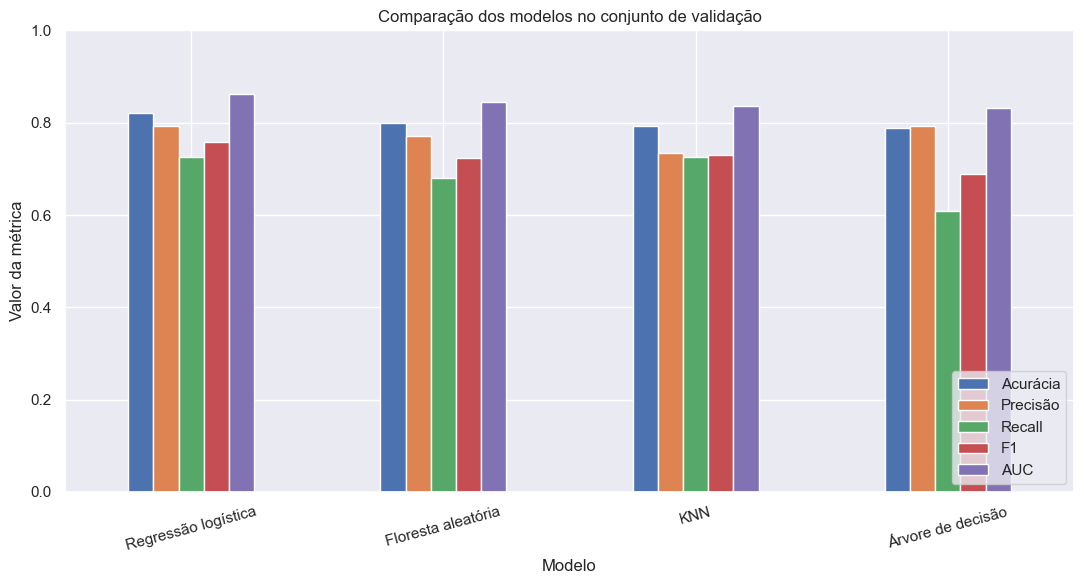

In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

def avaliar_modelo(modelo, X_avaliacao, y_avaliacao):
    y_pred = modelo.predict(X_avaliacao)
    y_prob = modelo.predict_proba(X_avaliacao)[:, 1]
    return {
        "Acurácia": accuracy_score(y_avaliacao, y_pred),
        "Precisão": precision_score(y_avaliacao, y_pred, zero_division=0),
        "Recall": recall_score(y_avaliacao, y_pred, zero_division=0),
        "F1": f1_score(y_avaliacao, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_avaliacao, y_prob)
    }

resultados_validacao = []
for nome_modelo, modelo in melhores_modelos_cv.items():
    metricas = avaliar_modelo(modelo, X_val, y_val)
    metricas["Modelo"] = nome_modelo
    resultados_validacao.append(metricas)

resultados_validacao_df = (
    pd.DataFrame(resultados_validacao).set_index("Modelo").sort_values("AUC", ascending=False)
)
display(resultados_validacao_df.round(4))

resultados_validacao_df.plot(kind="bar", figsize=(11, 6))
plt.ylim(0, 1)
plt.ylabel("Valor da métrica")
plt.title("Comparação dos modelos no conjunto de validação")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 9.5 - Matrizes de confusão

A matriz de confusão mostra, lado a lado, os acertos e os tipos de erro de cada modelo. Considerando `Sobreviveu = 1` como classe positiva:

- **verdadeiro negativo** (canto superior esquerdo): não sobreviveu e foi classificado corretamente;
- **falso positivo** (canto superior direito): não sobreviveu, mas foi classificado como sobrevivente;
- **falso negativo** (canto inferior esquerdo): sobreviveu, mas foi classificado como não sobrevivente;
- **verdadeiro positivo** (canto inferior direito): sobreviveu e foi classificado corretamente.

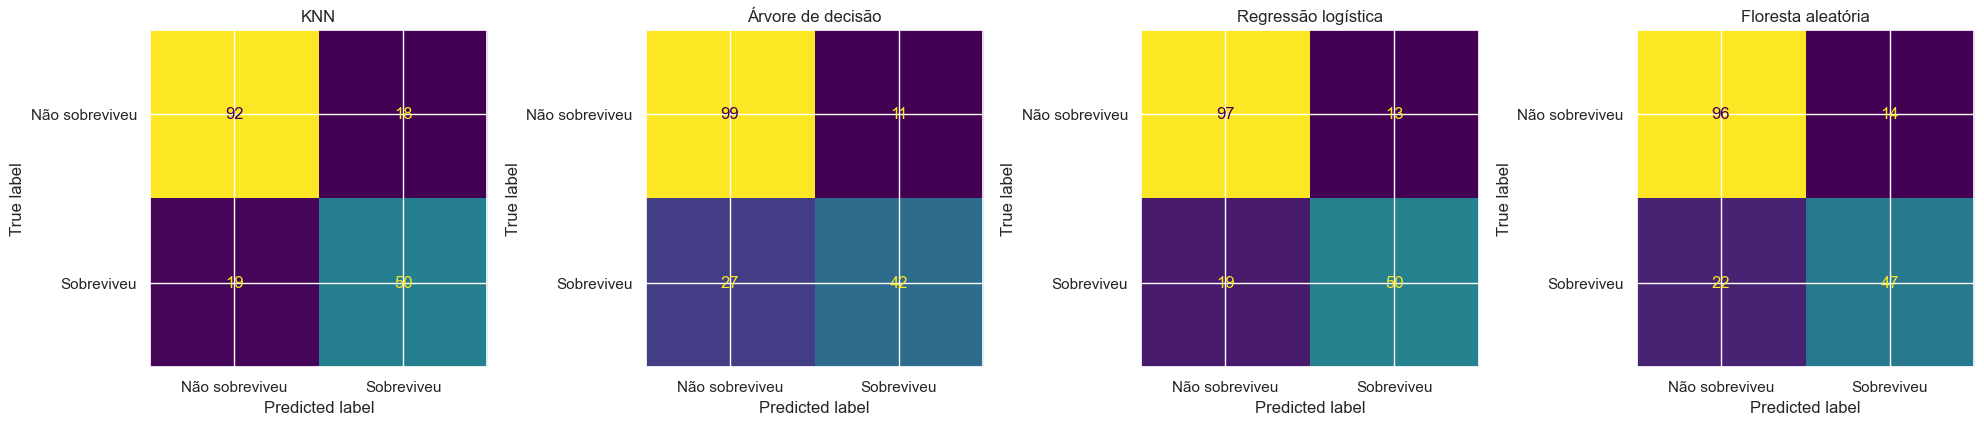

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, eixos = plt.subplots(1, 4, figsize=(20, 5))
for eixo, (nome_modelo, modelo) in zip(eixos, melhores_modelos_cv.items()):
    y_pred = modelo.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=["Não sobreviveu", "Sobreviveu"],
        values_format="d", ax=eixo, colorbar=False
    )
    eixo.set_title(nome_modelo)
plt.tight_layout()
plt.show()

### 9.6 - Curvas ROC

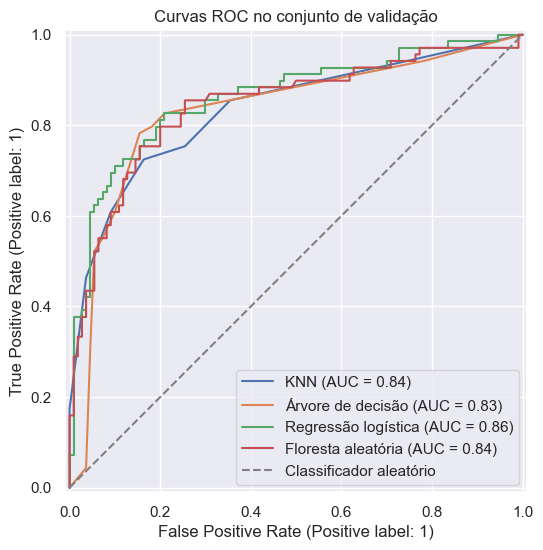

In [45]:
from sklearn.metrics import RocCurveDisplay

fig, eixo = plt.subplots(figsize=(7, 6))
for nome_modelo, modelo in melhores_modelos_cv.items():
    RocCurveDisplay.from_estimator(modelo, X_val, y_val, name=nome_modelo, ax=eixo)

eixo.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
eixo.set_title("Curvas ROC no conjunto de validação")
eixo.legend()
plt.show()

### 9.7 - Importância dos atributos na árvore de decisão (duas formas)

A árvore de decisão tem uma vantagem importante sobre modelos como KNN: ela é **interpretável**, e podemos medir quanto cada atributo contribuiu para as decisões do modelo. Vamos comparar **duas formas diferentes** de medir essa importância:

1. **Importância nativa da árvore** (`feature_importances_`): calculada a partir da própria estrutura da árvore, medindo o quanto cada atributo reduziu a impureza (Gini ou entropia) nos nós em que foi usado para dividir os dados. É rápida de calcular, mas pode favorecer atributos com muitos valores distintos ou atributos correlacionados entre si;
2. **Importância por permutação**: mede quanto a performance do modelo **cai** quando embaralhamos aleatoriamente os valores de um atributo (destruindo sua relação com o alvo), mantendo os demais atributos intactos. É mais custosa computacionalmente, mas costuma ser mais confiável, pois mede o impacto real no desempenho do modelo, e pode ser aplicada com qualquer modelo (não só árvores).

In [47]:
arvore_final = melhores_modelos_cv["Árvore de decisão"]

# --- Forma 1: importância nativa da árvore (baseada nos atributos originais/estrutura da árvore) ---
importancias_nativas = arvore_final.feature_importances_
indices_nativa = np.argsort(importancias_nativas)[::-1]

importancia_nativa_df = pd.DataFrame({
    "Atributo": [feature_names[i] for i in indices_nativa],
    "Importância nativa": importancias_nativas[indices_nativa]
})

display(importancia_nativa_df.head(15))

,Atributo,Importância nativa
0,Title_Mr,0.499424
1,Pclass,0.123296
2,FamilySize,0.074202
3,Deck_Unknown,0.072244
4,FarePerPerson,0.061587
5,Fare,0.054875
6,Title_Rare,0.048757
7,Age,0.030340
8,TicketGroupSize,0.017805
9,Parch,0.013350


In [48]:
from sklearn.inspection import permutation_importance

# --- Forma 2: importância por permutação (calculada no conjunto de validação) ---
resultado_permutacao = permutation_importance(
    arvore_final, X_val, y_val, scoring="roc_auc", n_repeats=30, random_state=42, n_jobs=-1
)

importancia_permutacao_df = pd.DataFrame({
    "Atributo": feature_names,
    "Importância por permutação (média)": resultado_permutacao.importances_mean,
    "Desvio-padrão": resultado_permutacao.importances_std
}).sort_values("Importância por permutação (média)", ascending=False)

display(importancia_permutacao_df.head(15))

,Atributo,Importância por permutação (média),Desvio-padrão
13,Title_Mr,0.243013,0.037946
0,Pclass,0.051353,0.014585
5,FamilySize,0.046451,0.013817
8,FarePerPerson,0.023812,0.018875
24,Deck_Unknown,0.010312,0.011949
1,Age,0.006621,0.004552
3,Parch,0.004890,0.004822
4,Fare,0.004668,0.004019
7,TicketGroupSize,0.002585,0.009019
15,Title_Rare,0.001605,0.005393


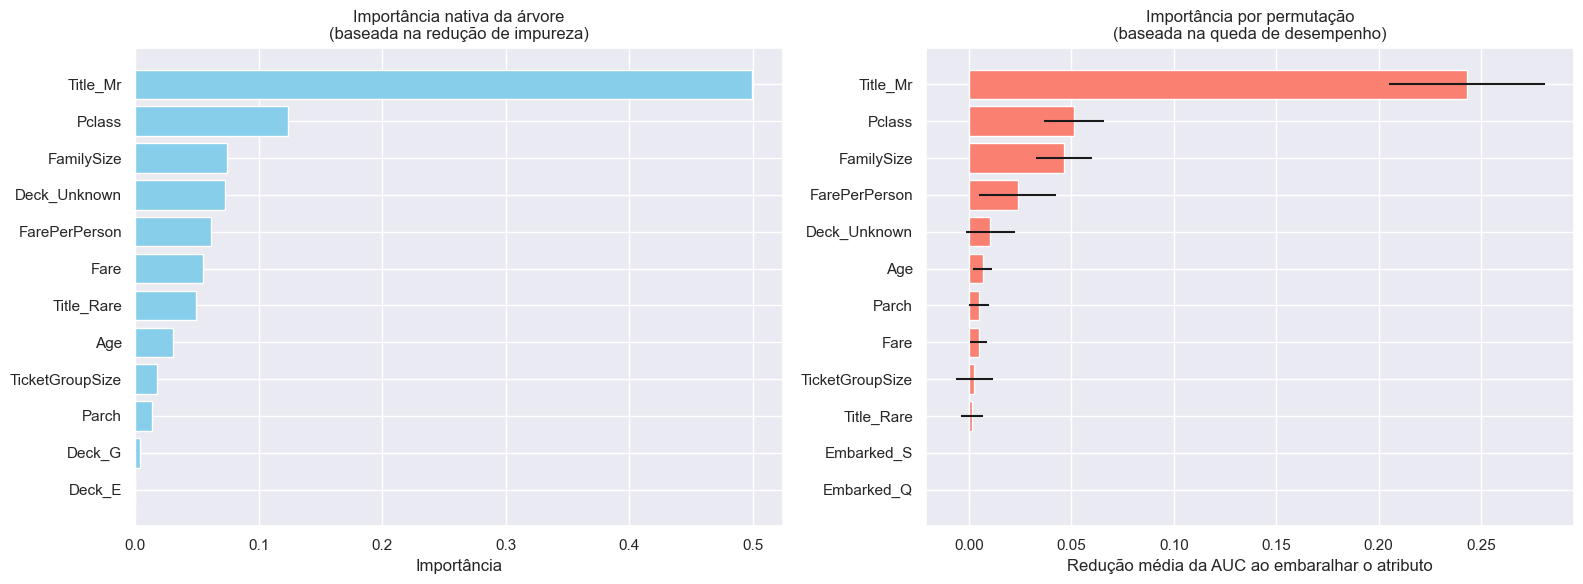

In [49]:
top_n = 12

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(16, 6))

top_nativa = importancia_nativa_df.head(top_n).sort_values("Importância nativa")
eixo1.barh(top_nativa["Atributo"], top_nativa["Importância nativa"], color="skyblue")
eixo1.set_title("Importância nativa da árvore\n(baseada na redução de impureza)")
eixo1.set_xlabel("Importância")

top_permutacao = importancia_permutacao_df.head(top_n).sort_values("Importância por permutação (média)")
eixo2.barh(
    top_permutacao["Atributo"], top_permutacao["Importância por permutação (média)"],
    xerr=top_permutacao["Desvio-padrão"], color="salmon"
)
eixo2.set_title("Importância por permutação\n(baseada na queda de desempenho)")
eixo2.set_xlabel("Redução média da AUC ao embaralhar o atributo")

plt.tight_layout()
plt.show()

Comparando as duas listas: em geral, os atributos mais importantes tendem a aparecer nos dois métodos (como `Sex_male` e algum atributo relacionado a `Title` ou `Pclass`), o que reforça a confiança nesse resultado. Mas é comum que a **ordem relativa** mude um pouco entre os dois métodos, especialmente entre atributos correlacionados entre si (por exemplo, `Fare` e `Pclass`, ou `FamilySize` e `SibSp`/`Parch`) — quando dois atributos carregam informação parecida, a importância "nativa" da árvore pode se concentrar mais em um deles (o que ela escolheu usar primeiro nas divisões), enquanto a importância por permutação reflete melhor o quanto cada atributo, isoladamente, contribui para o desempenho final.

### 9.8 - Escolha do melhor modelo

Combinando a validação cruzada (Seção 9.3) e a avaliação no conjunto de validação (Seção 9.4), podemos apontar o modelo com melhor equilíbrio geral. Vamos usar a **AUC no conjunto de validação** como critério final de desempate, por ser a métrica mais robusta a desbalanceamento de classes.

In [50]:
melhor_modelo_nome = resultados_validacao_df["AUC"].idxmax()
print(f"Melhor modelo (por AUC no conjunto de validação): {melhor_modelo_nome}")
display(resultados_validacao_df.loc[[melhor_modelo_nome]].round(4))

Melhor modelo (por AUC no conjunto de validação): Regressão logística


,Acurácia,Precisão,Recall,F1,AUC
Modelo,,,,,
Regressão logística,0.8212,0.7937,0.7246,0.7576,0.8617


### 9.9 - Reajuste final e geração das submissões para o Kaggle

Vamos gerar as previsões finais. Diferentemente da avaliação da Seção 9.4 (que usou apenas o subconjunto `X_tr`, para reservar `X_val` como conjunto de validação), agora vamos **reajustar cada modelo usando todos os dados de treinamento disponíveis** (`X_train`, `y_train` completos), sem desperdiçar nenhuma observação, mantendo os melhores hiperparâmetros encontrados na Seção 9.3. Em seguida, aplicamos cada modelo ao conjunto de teste real do Kaggle (`X_test`) e salvamos **um arquivo de submissão para cada um dos quatro modelos**.

In [51]:
from sklearn.base import clone

nomes_arquivos = {
    "KNN": "Titanic-knn-final.csv",
    "Árvore de decisão": "Titanic-arvore-decisao-final.csv",
    "Regressão logística": "Titanic-regressao-logistica-final.csv",
    "Floresta aleatória": "Titanic-floresta-aleatoria-final.csv"
}

arquivos_gerados = []

for nome_modelo in modelos_base:
    # Clona o modelo (mesmos hiperparâmetros encontrados na Seção 9.3), sem copiar o ajuste anterior,
    # e o reajusta usando TODOS os dados de treinamento disponíveis (X_train, y_train completos)
    modelo_final = clone(melhores_modelos_cv[nome_modelo])
    modelo_final.fit(X_train, y_train)

    y_pred_final = modelo_final.predict(X_test)
    y_pred_final = np.array(y_pred_final, dtype=int)

    submissao = pd.DataFrame()
    submissao["PassengerId"] = PassengerId_test
    submissao["Survived"] = y_pred_final

    nome_arquivo = nomes_arquivos[nome_modelo]
    submissao.to_csv(nome_arquivo, index=False)
    arquivos_gerados.append(nome_arquivo)

    print(f"[{nome_modelo}] arquivo gerado: {nome_arquivo}  "
          f"({submissao['Survived'].sum()} previsões de sobrevivência em {len(submissao)} passageiros)")

print("\nTodos os arquivos de submissão foram gerados:")
for arquivo in arquivos_gerados:
    print(" -", arquivo)

[KNN] arquivo gerado: Titanic-knn-final.csv  (172 previsões de sobrevivência em 418 passageiros)
[Árvore de decisão] arquivo gerado: Titanic-arvore-decisao-final.csv  (161 previsões de sobrevivência em 418 passageiros)
[Regressão logística] arquivo gerado: Titanic-regressao-logistica-final.csv  (166 previsões de sobrevivência em 418 passageiros)
[Floresta aleatória] arquivo gerado: Titanic-floresta-aleatoria-final.csv  (154 previsões de sobrevivência em 418 passageiros)

Todos os arquivos de submissão foram gerados:
 - Titanic-knn-final.csv
 - Titanic-arvore-decisao-final.csv
 - Titanic-regressao-logistica-final.csv
 - Titanic-floresta-aleatoria-final.csv


Cada um desses arquivos pode ser enviado separadamente à competição do Titanic no Kaggle, permitindo comparar o desempenho real (na base de teste oculta do Kaggle) com o que estimamos aqui usando validação cruzada e o conjunto de validação. Se os resultados no Kaggle forem parecidos com o que vimos nas Seções 9.3 e 9.4, isso é um bom sinal de que nossa validação foi confiável; grandes diferenças indicariam que talvez estejamos superajustando (*overfitting*) aos dados de treinamento.

## Exercício de fixação

Tente melhorar a classificação no Kaggle. Dicas:<br>
* Use o Random Forest sem o one-hot-encoding (ele lida bem com variáveis categóricas codificadas como inteiros).<br>
* Use outros classificadores.<br>
* Use outros hiperparâmetros nos modelos que consideramos. Veja a documentação cada um para conhecer os hiperparâmetros que podem ser ajustados.

## Use outros classificadores - XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform, randint

param_dist = {
    "n_estimators": randint(100, 600), # número de árvores
    "max_depth": randint(2, 8), # profundidade máxima de cada árvore
    "learning_rate": loguniform(0.01, 0.2), # taxa de aprendizado
    "subsample": uniform(0.7, 0.3),  # taxa de amostragem de linhas para cada árvore
    "colsample_bytree": uniform(0.7, 0.3), # taxa de amostragem de colunas para cada árvore
    "min_child_weight": randint(1, 10), # peso mínimo de cada folha
    "gamma": uniform(0, 5), # penalidade de complexidade da árvore
    "reg_alpha": loguniform(1e-3, 10), # penalidade L1
    "reg_lambda": loguniform(1e-2, 50), # penalidade L2
}

grid_search_xg = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective="binary:logistic", 
        eval_metric="auc",
        tree_method="hist", 
        random_state=42, 
        n_jobs=1
    ),
    param_distributions=param_dist,
    n_iter=150, # número de combinações de hiperparâmetros a serem testadas
    cv=5,
    scoring="roc_auc", # métrica de avaliação
    n_jobs=-1, # usa todos os núcleos disponíveis para acelerar o processo 
    random_state=42,
    verbose=2, # mostra o progresso do ajuste
)
grid_search_xg.fit(X_train, y_train)

print("Melhores hiperparâmetros (XGBoost):", grid_search_xg.best_params_)
print("Melhor AUC na validação cruzada (XGBoost):", grid_search_xg.best_score_)

y_train_pred_proba = grid_search_xg.predict_proba(X_train)[:, 1]
train_auc_xg = roc_auc_score(y_train, y_train_pred_proba)
print("AUC no conjunto de treinamento (XGBoost):", train_auc_xg)

# Previsão no conjunto de teste e geração do arquivo de submissão
y_pred_xg = grid_search_xg.predict(X_test)
y_pred_xg = np.array(y_pred_xg, dtype=int) 

prediction_xg = pd.DataFrame()
prediction_xg['PassengerId'] = PassengerId_test
prediction_xg['Survived'] = y_pred_xg
# prediction_xg.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-xgboost.csv', index=False)

prediction_xg.head()

In [128]:
import xgboost as xgb

# Define o espaço de busca para os hiperparâmetros do XGBoost
'''
Eu escoli parâmetros que são comumente ajustados em problemas de classificação binária.
Mas, sem muito critério na escolha dos valores, apenas para demonstrar o uso do GridSearchCV.
- n_estimators: número de árvores na floresta (quanto maior, mais complexo o modelo)
- max_depth: profundidade máxima das árvores (quanto maior, mais complexo o modelo)
- learning_rate: taxa de aprendizado (quanto menor, mais lento o aprendizado, mas pode melhorar a generalização)
- subsample: proporção de amostras usadas para treinar cada árvore (quanto menor, mais robusto o modelo, mas pode aumentar o viés)
- colsample_bytree: proporção de atributos usados para treinar cada árvore (quanto menor, mais robusto o modelo, mas pode aumentar o viés)  
- min_child_weight: peso mínimo de uma folha (quanto maior, mais conservador o modelo)
- gamma: redução mínima de perda necessária para fazer uma divisão (quanto maior, mais conservador o modelo)    
- reg_alpha: regularização L1 (quanto maior, mais conservador o modelo)
- reg_lambda: regularização L2 (quanto maior, mais conservador o modelo)
'''

param_grid_xg = {
"n_estimators": [50, 100, 150], # número de árvores na floresta
"max_depth": [2, 4, 6], # profundidade máxima das árvores
"learning_rate": [0.05, 0.1] # taxa de aprendizado
}

# Cria o classificador XGBoost
xg_classifier = xgb.XGBClassifier(objective="binary:logistic", 
                                  eval_metric="auc", 
                                  random_state=42)

grid_search_xg = GridSearchCV(estimator=xg_classifier, 
                              param_grid=param_grid_xg, 
                              cv=5,
                              scoring='roc_auc', 
                              verbose=2, 
                              n_jobs=1) # n_jobs=1 para evitar problemas de memória com o XGBoost

grid_search_xg.fit(X_train, y_train)

print("Melhores hiperparâmetros (XGBoost):", grid_search_xg.best_params_)
print("Melhor AUC na validação cruzada (XGBoost):", grid_search_xg.best_score_)

y_train_pred_proba = grid_search_xg.predict_proba(X_train)[:, 1]
train_auc_xg = roc_auc_score(y_train, y_train_pred_proba)
print("AUC no conjunto de treinamento (XGBoost):", train_auc_xg)

# Previsão no conjunto de teste e geração do arquivo de submissão
y_pred_xg = grid_search_xg.predict(X_test)
y_pred_xg = np.array(y_pred_xg, dtype=int) 

prediction_xg = pd.DataFrame()
prediction_xg['PassengerId'] = PassengerId_test
prediction_xg['Survived'] = y_pred_xg
prediction_xg.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-xgboost.csv', index=False)

prediction_xg.head()

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ...learning_rate=0.05, max_depth=2, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.05, max_depth=2, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.05, max_depth=2, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.05, max_depth=2, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.05, max_depth=2, n_estimators=50; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=150; total time=   0.0s
[CV] END ..learning_rate=0.05, max_depth=2, n_es

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Esse modelo alcançou um score de 0.74401 no Kaggle.

In [ ]:
import xgboost as xgb

# Define o espaço de busca para os hiperparâmetros do XGBoost
'''
Eu escoli parâmetros que são comumente ajustados em problemas de classificação binária.
Mas, sem muito critério na escolha dos valores, apenas para demonstrar o uso do GridSearchCV.
- n_estimators: número de árvores na floresta (quanto maior, mais complexo o modelo)
- max_depth: profundidade máxima das árvores (quanto maior, mais complexo o modelo)
- learning_rate: taxa de aprendizado (quanto menor, mais lento o aprendizado, mas pode melhorar a generalização)
- subsample: proporção de amostras usadas para treinar cada árvore (quanto menor, mais robusto o modelo, mas pode aumentar o viés)
- colsample_bytree: proporção de atributos usados para treinar cada árvore (quanto menor, mais robusto o modelo, mas pode aumentar o viés)  
- min_child_weight: peso mínimo de uma folha (quanto maior, mais conservador o modelo)
- gamma: redução mínima de perda necessária para fazer uma divisão (quanto maior, mais conservador o modelo)    
- reg_alpha: regularização L1 (quanto maior, mais conservador o modelo)
- reg_lambda: regularização L2 (quanto maior, mais conservador o modelo)
'''

param_grid_xg = {
"n_estimators": [150], # número de árvores na floresta
"max_depth": [4], # profundidade máxima das árvores
"learning_rate": [0.1], # taxa de aprendizado
"min_child_weight": [1, 3, 5],
"gamma": [0, 0.1, 0.3],
"reg_alpha": [0, 0.1, 1],
"reg_lambda": [1, 10]
}

# Cria o classificador XGBoost
xg_classifier = xgb.XGBClassifier(objective="binary:logistic", 
                                  eval_metric="auc", 
                                  random_state=42)

grid_search_xg = GridSearchCV(estimator=xg_classifier, 
                              param_grid=param_grid_xg, 
                              cv=5,
                              scoring='roc_auc', 
                              verbose=2, 
                              n_jobs=1) # n_jobs=1 para evitar problemas de memória com o XGBoost

grid_search_xg.fit(X_train, y_train)

print("Melhores hiperparâmetros (XGBoost):", grid_search_xg.best_params_)
print("Melhor AUC na validação cruzada (XGBoost):", grid_search_xg.best_score_)

y_train_pred_proba = grid_search_xg.predict_proba(X_train)[:, 1]
train_auc_xg = roc_auc_score(y_train, y_train_pred_proba)
print("AUC no conjunto de treinamento (XGBoost):", train_auc_xg)

# Previsão no conjunto de teste e geração do arquivo de submissão
y_pred_xg = grid_search_xg.predict(X_test)
y_pred_xg = np.array(y_pred_xg, dtype=int) 

prediction_xg = pd.DataFrame()
prediction_xg['PassengerId'] = PassengerId_test
prediction_xg['Survived'] = y_pred_xg
prediction_xg.to_csv('C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\14-Projeto_titanic\\final_predictions\\Titanic-xgboost-v2.csv', index=False)

prediction_xg.head()

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=1; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=1; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=1; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=1; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=1; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=10; total time=   0.0s
[CV] END gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=150, reg_alpha=0, reg_lambda=10; total time=   0.0

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## Esse modelo alcançou um score de 0.76076 no Kaggle.